#                                  timeseris Regresi - RNN

# Load Data

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:

file_name = "microsoft_stock_data"
root_folder = f'timeseris/regresi/rnn/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,3/26/1986,0.057906,0.058437,0.055781,0.056312,22752000
1,3/27/1986,0.058969,0.058969,0.057906,0.057906,16848000
2,3/31/1986,0.058437,0.058969,0.057375,0.058969,12873600
3,4/1/1986,0.057906,0.058437,0.057906,0.058437,11088000
4,4/2/1986,0.058437,0.059500,0.057906,0.057906,27014400


#### Pilih tahun mulai data

In [3]:
# Pastikan kolom Date dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data mulai dari tahun 2000
df = df[df['Date'] >= '1999-01-01']

# (Opsional) urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800


#### tambahkan status green, red, dan netral || DayName

In [4]:
# === Tambahkan kolom nama hari ===
df['Day'] =  df['Date'].dt.day_name()  # bahasa Inggris


df.head()

,Date,Close,High,Low,Open,Volume,Day
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday


#### LabelEncoder

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_Day']            = le.fit_transform(df['Day'])




In [7]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,label_Day
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday,1
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday,3
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday,4
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday,2
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday,0


#### Scaler

In [59]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_Day',
    'Close', 
    'High', 
    'Low',
    'Open',
    'Volume', 
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_Day' saved as scaler_label_Day.pkl
✅ Scaler for 'Close' saved as scaler_Close.pkl
✅ Scaler for 'High' saved as scaler_High.pkl
✅ Scaler for 'Low' saved as scaler_Low.pkl
✅ Scaler for 'Open' saved as scaler_Open.pkl
✅ Scaler for 'Volume' saved as scaler_Volume.pkl

All individual scalers saved successfully!


In [60]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day,label_Status
0,1999-01-04,0.019888,0.019737,0.019942,0.018714,0.106426,Monday,green,0.25,0
1,1999-01-05,0.021495,0.020511,0.020549,0.019352,0.097822,Tuesday,green,0.75,0
2,1999-01-06,0.022883,0.021498,0.022111,0.021500,0.106014,Wednesday,green,1.00,0
3,1999-01-07,0.022664,0.021251,0.022553,0.021571,0.075333,Thursday,green,0.50,0
4,1999-01-08,0.022482,0.021779,0.022185,0.022257,0.073782,Friday,red,0.00,1


#### Mapping label

In [61]:
import json
mapping_dicts = {}

cols = [
    'Day',
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
print(mapping_table)

  feature original_value  label_value
0     Day         Monday         0.25
1     Day        Tuesday         0.75
2     Day      Wednesday         1.00
3     Day       Thursday         0.50
4     Day         Friday         0.00


#### Select Kolom To Trian

In [62]:
col_target = 'label_Status'
cols = [
    'Date',
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
    col_target
]
df = df[cols].copy()
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,label_Status
0,1999-01-04,0.25,0.019888,0.019737,0.019942,0.018714,0.106426,0
1,1999-01-05,0.75,0.021495,0.020511,0.020549,0.019352,0.097822,0
2,1999-01-06,1.00,0.022883,0.021498,0.022111,0.021500,0.106014,0
3,1999-01-07,0.50,0.022664,0.021251,0.022553,0.021571,0.075333,0
4,1999-01-08,0.00,0.022482,0.021779,0.022185,0.022257,0.073782,1


# Data Load To Train

#### select Future to traian

In [63]:
feature_cols = [
    'label_Day', 
    'Close', 
    #'High',
    #'Low',
    'Open',
    #'Volume',
]
target_cols = col_target

#### Split data

In [64]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tgl_pembatas = '2021-01-01'
X_train = df[df['Date'] <= tgl_pembatas]
X_test  = df[df['Date'] > tgl_pembatas]
print(f'Train : f{X_train.shape}')
print(f'Test  : f{X_test.shape}')

Train : f(5536, 8)
Test  : f(1204, 8)


#### DataLoader

In [65]:
from data_set import MultiClassTimeSeriesDataset
seq_length = 20
slide      = 1
# Buat dataset dengan class kamu
train_dataset = MultiClassTimeSeriesDataset(X_train,seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols, normalize=False)
test_dataset  = MultiClassTimeSeriesDataset(X_test, seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X shape: torch.Size([32, 20, 3])
y shape: torch.Size([32])
tensor([[[0.7500, 0.0254, 0.0236],
         [0.5000, 0.0253, 0.0242],
         [0.0000, 0.0245, 0.0242],
         [0.2500, 0.0242, 0.0235],
         [0.7500, 0.0238, 0.0234],
         [1.0000, 0.0232, 0.0229],
         [0.5000, 0.0222, 0.0221],
         [0.0000, 0.0233, 0.0215],
         [0.2500, 0.0234, 0.0225],
         [0.7500, 0.0237, 0.0228],
         [1.0000, 0.0249, 0.0227],
         [0.5000, 0.0253, 0.0240],
         [0.0000, 0.0244, 0.0248],
         [0.2500, 0.0231, 0.0227],
         [0.7500, 0.0229, 0.0222],
         [1.0000, 0.0225, 0.0222],
         [0.5000, 0.0230, 0.0222],
         [0.0000, 0.0239, 0.0225],
         [0.2500, 0.0237, 0.0229],
         [0.7500, 0.0234, 0.0225]],

        [[0.2500, 0.0172, 0.0161],
         [0.7500, 0.0165, 0.0164],
         [1.0000, 0.0156, 0.0158],
         [0.5000, 0.0165, 0.0148],
         [0.0000, 0.0149, 0.0153],
         [0.2500, 0.0153, 0.0141],
         [0.7500, 0.0142, 0.0

# Config

In [66]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_size"     : len(test_dataset[0][0][0]),
    "hidden_size"    : 32,
    "num_layers"     : 1,
    "output_size"    : len(labels),
    "dropout"        : 0.1,
    "bidirectional"  : True,
    "early_stop_patience" : 30,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(bidirectional=True, col_target=label_Status, dropout=0.1, early_stop_patience=30, feature_cols=['label_Day', 'Close', 'Open'], hidden_size=32, input_size=3, labels={0: 'green', 1: 'red'}, num_layers=1, output_size=2, threshold=0.5)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [74]:
from class_lib import RNN_Pure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False
model = RNN_Pure(
    input_size=config.input_size, 
    hidden_size=config.hidden_size, 
    num_layers=config.num_layers, 
    output_size=config.output_size, 
    dropout=config.dropout, 
    bidirectional=config.bidirectional
).to(device)

#Criterion
criterion =nn.CrossEntropyLoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.6)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

/home/arindyproject/miniconda3/envs/ai2/lib/python3.8/site-packages/torch/nn/modules/rnn.py:47: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1060.69it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6941 │ │ green │  0.0000  │
│ Accuracy │ 0.5013 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3750 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

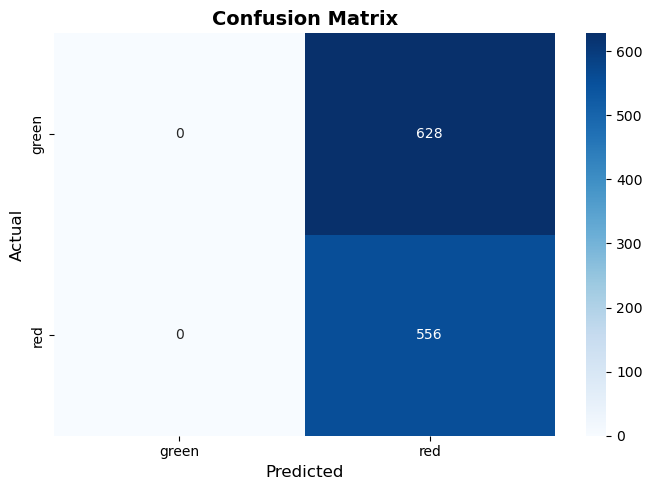


Epoch     1
Train_cost  = 0.6932 | Test_cost  = 0.6941 | Train_score = 0.5013 | Test_score = 0.4696 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 976.05it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6942 │ │ green │  0.0000  │
│ Accuracy │ 0.5011 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3523 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

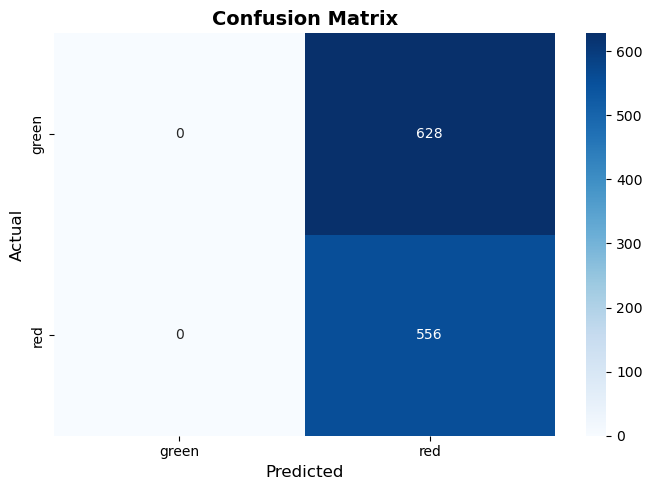


Epoch     2
Train_cost  = 0.6932 | Test_cost  = 0.6942 | Train_score = 0.5011 | Test_score = 0.4696 |
==> EarlyStop patience =  1 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1130.63it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6943 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

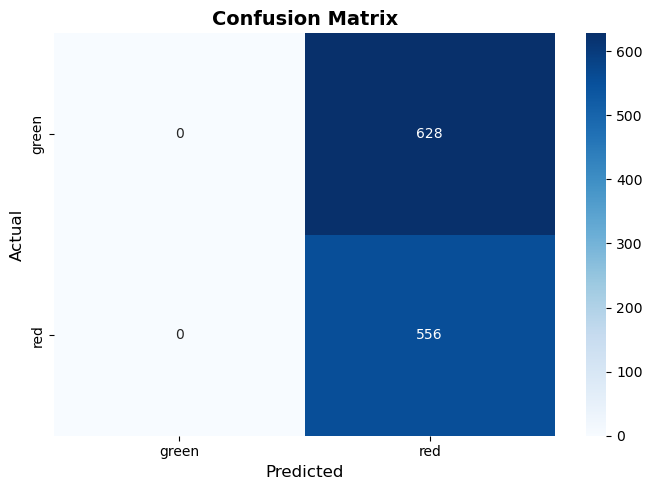


Epoch     3
Train_cost  = 0.6932 | Test_cost  = 0.6943 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  2 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1108.13it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

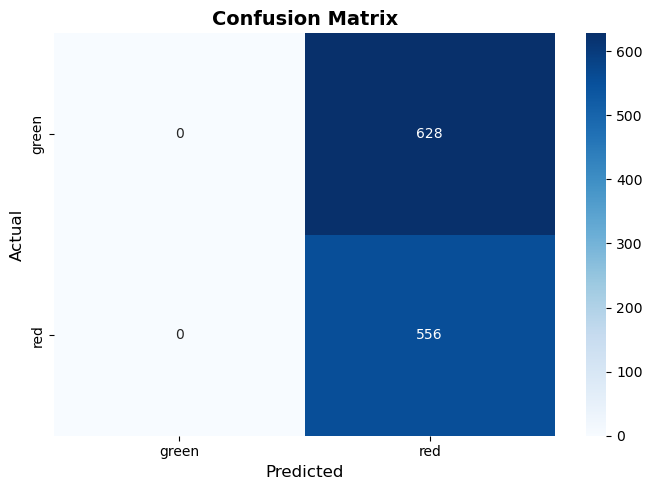


Epoch     4
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  3 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 980.21it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

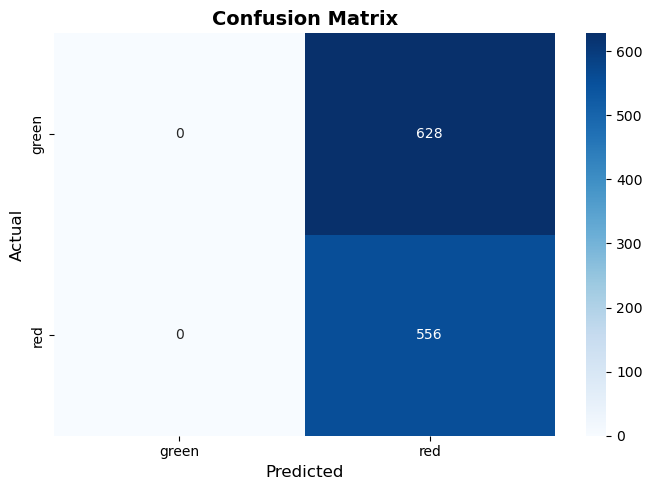


Epoch     5
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  4 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1126.61it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

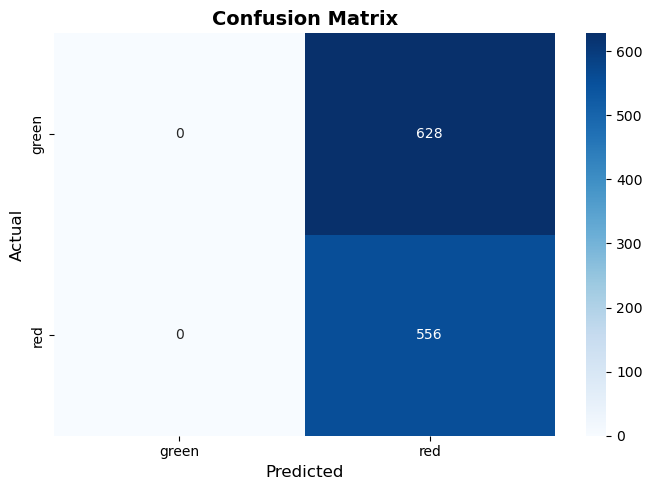


Epoch     6
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  5 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1145.82it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

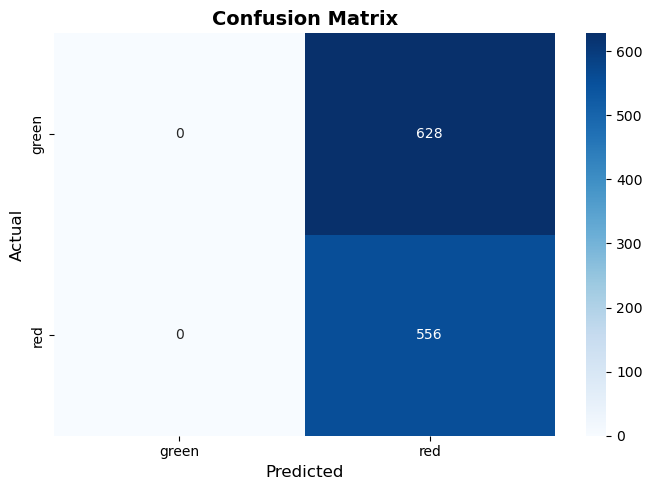


Epoch     7
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  6 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1072.27it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

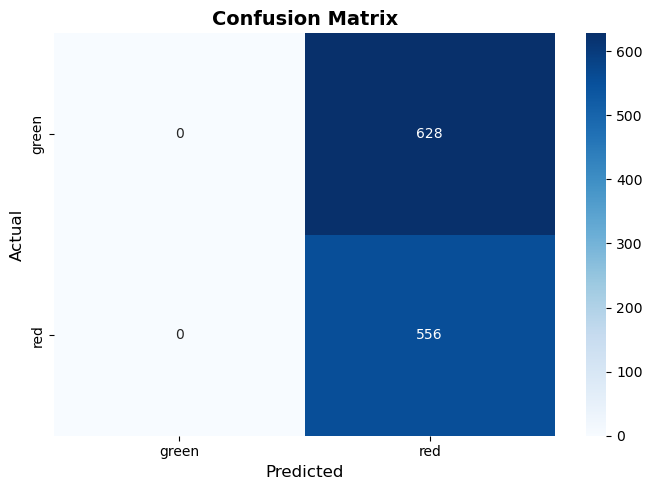


Epoch     8
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  7 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 976.48it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

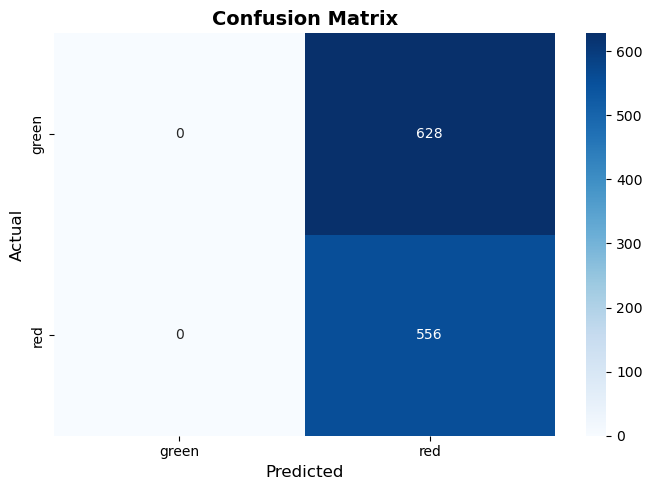


Epoch     9
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  8 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 880.32it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

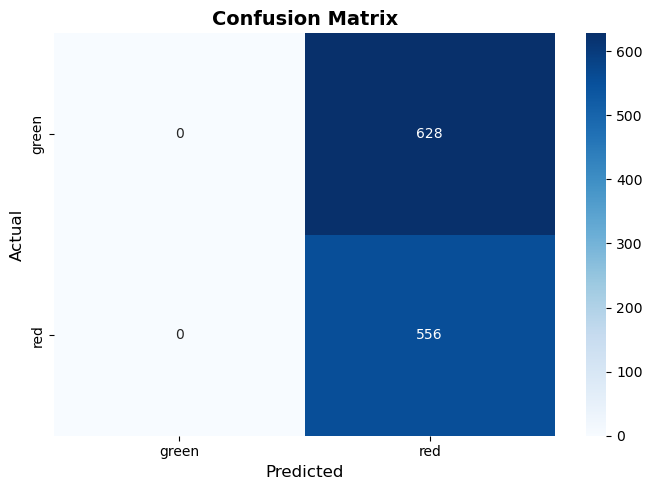


Epoch    10
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience =  9 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1008.79it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

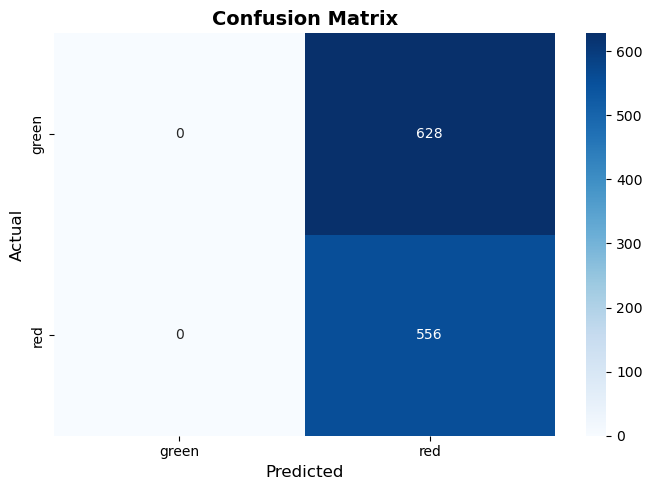


Epoch    11
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 10 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1095.12it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

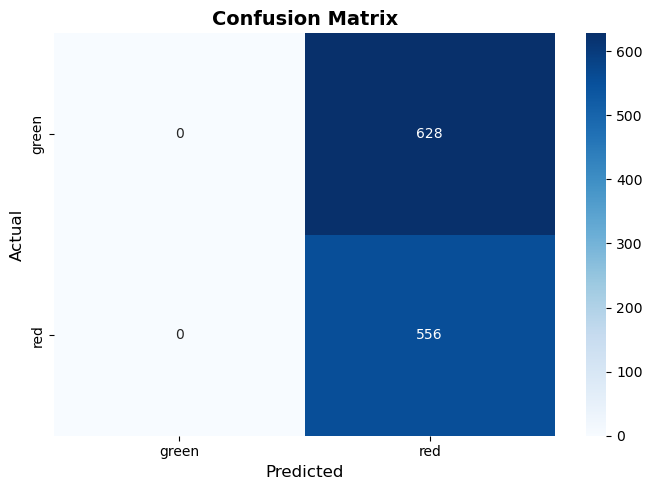


Epoch    12
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 11 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1125.66it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

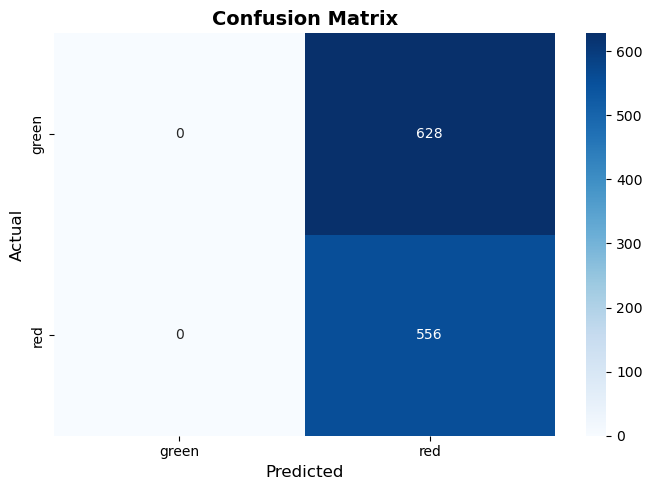


Epoch    13
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 12 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1139.73it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

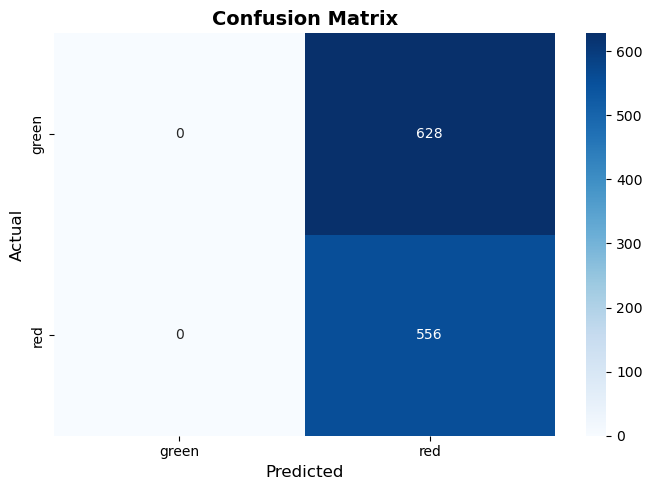


Epoch    14
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 13 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 985.49it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

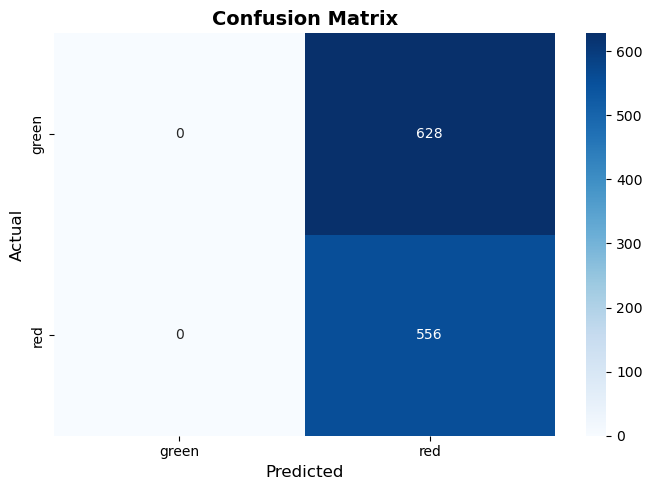


Epoch    15
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 14 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1110.65it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6945 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

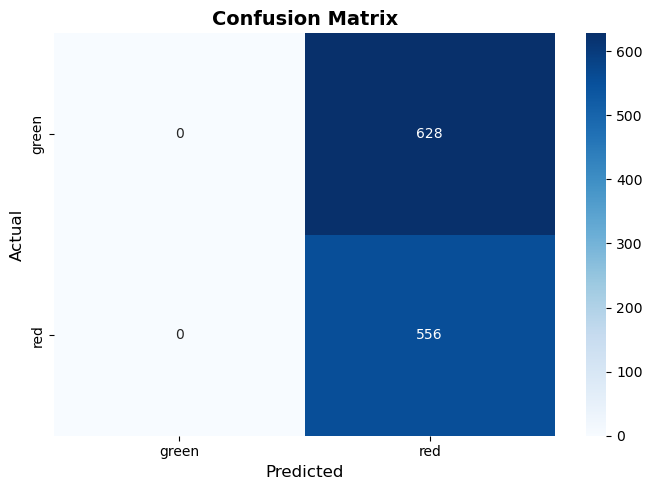


Epoch    16
Train_cost  = 0.6932 | Test_cost  = 0.6945 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 15 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1085.00it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

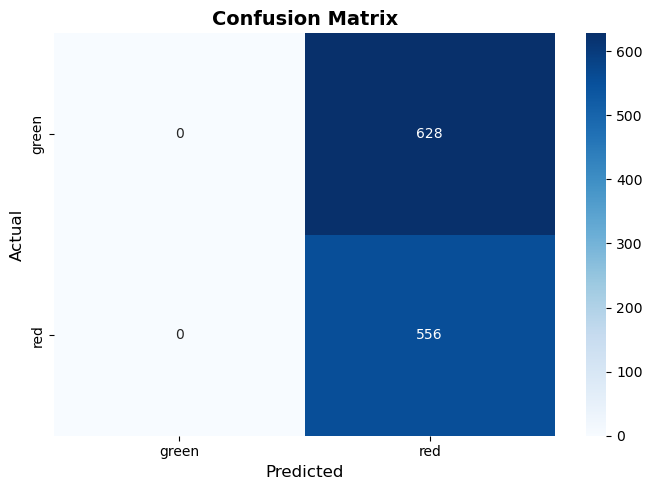


Epoch    17
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 16 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1122.32it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

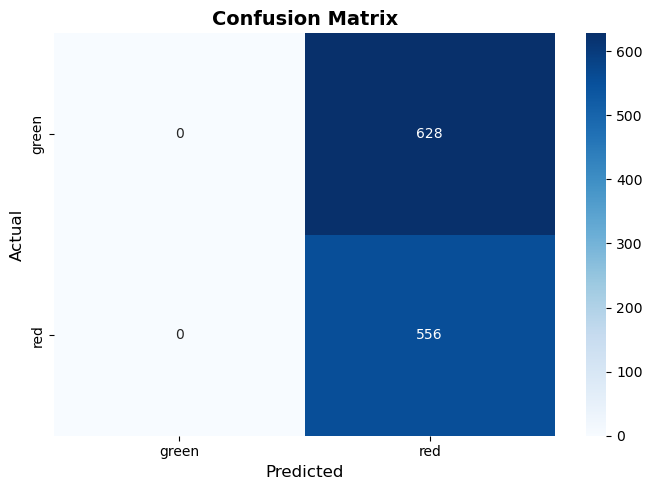


Epoch    18
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 17 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1114.70it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

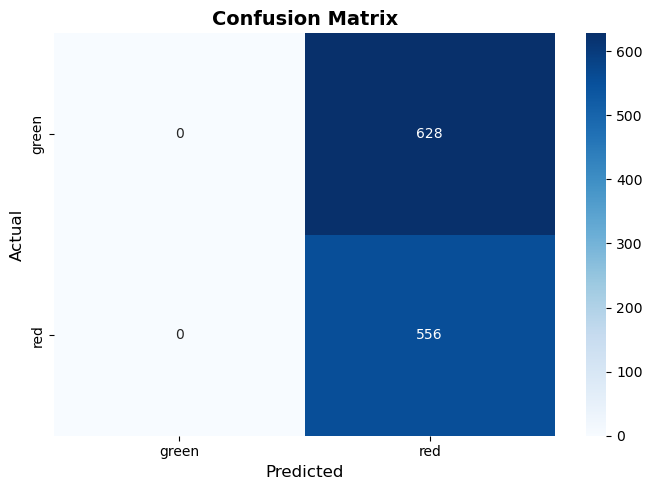


Epoch    19
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 18 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1040.31it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

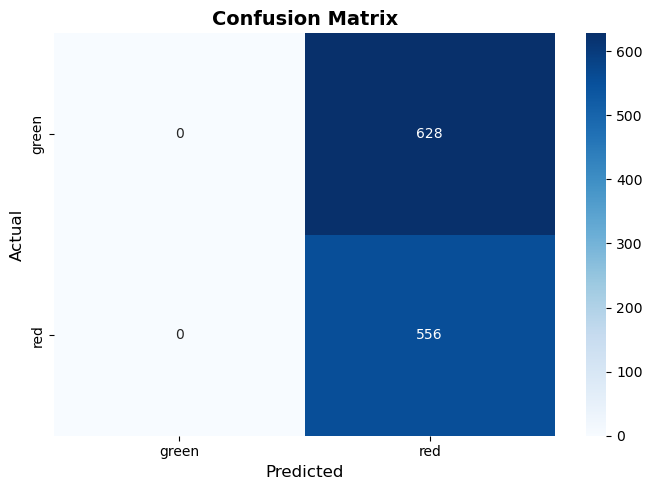


Epoch    20
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |


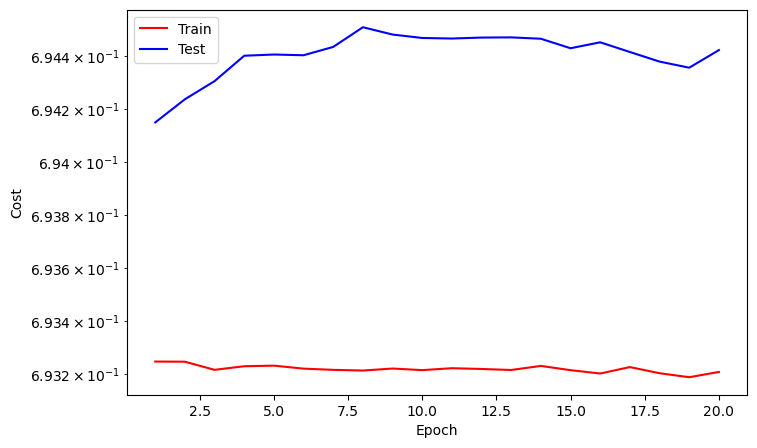

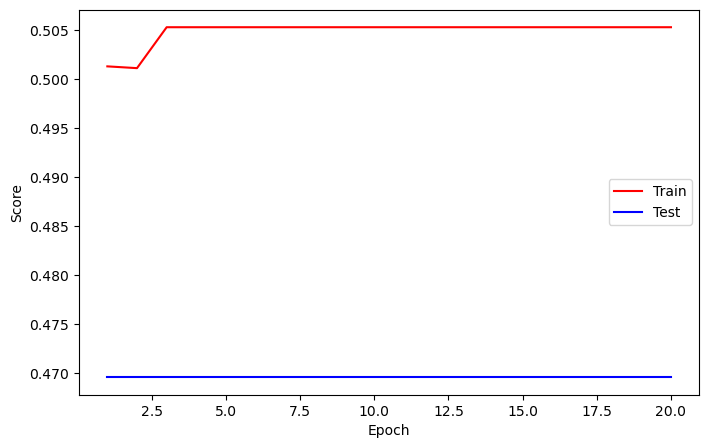

==> EarlyStop patience = 19 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1130.56it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

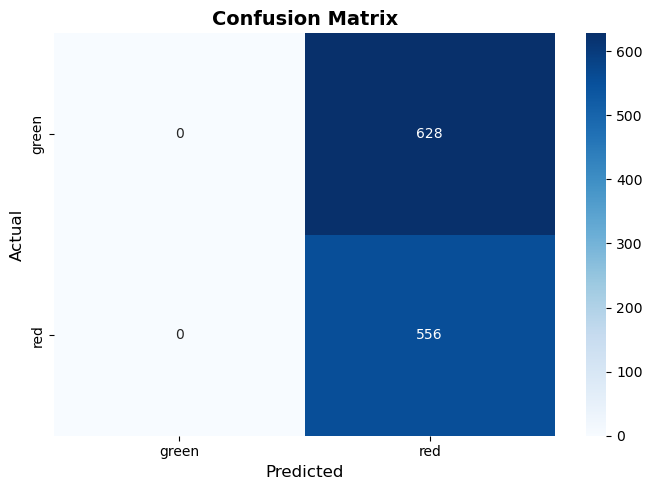


Epoch    21
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 20 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 22 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1094.44it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

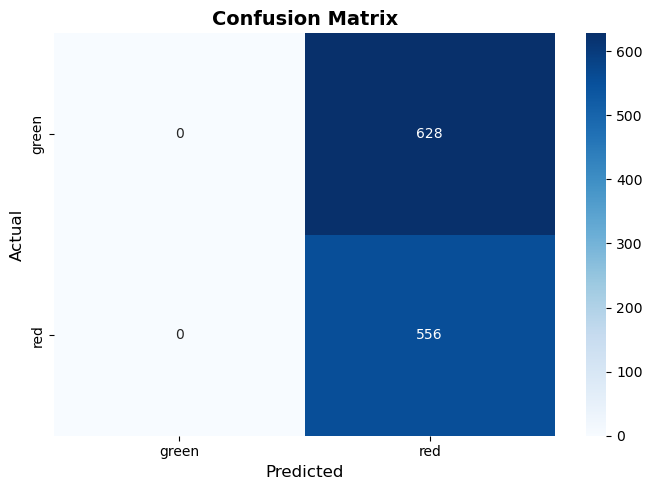


Epoch    22
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 21 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 23 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1088.83it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

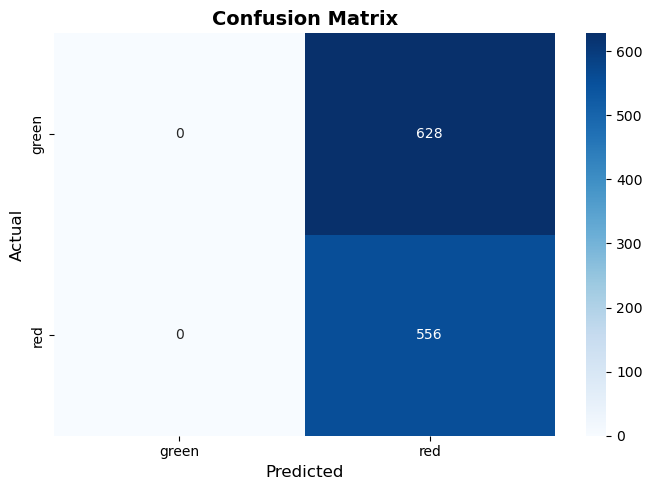


Epoch    23
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 22 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 24 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1108.54it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

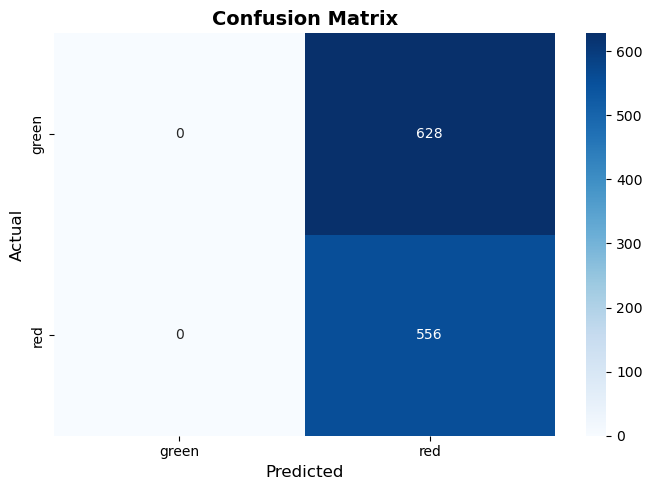


Epoch    24
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 23 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 25 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1171.55it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6943 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

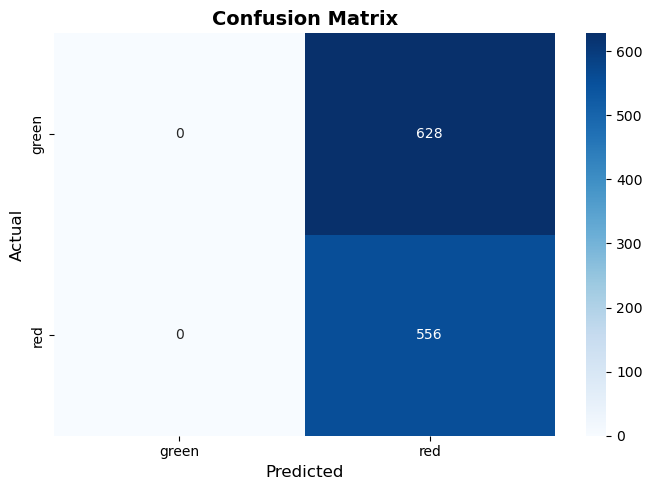


Epoch    25
Train_cost  = 0.6932 | Test_cost  = 0.6943 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 24 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 26 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1106.67it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6943 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

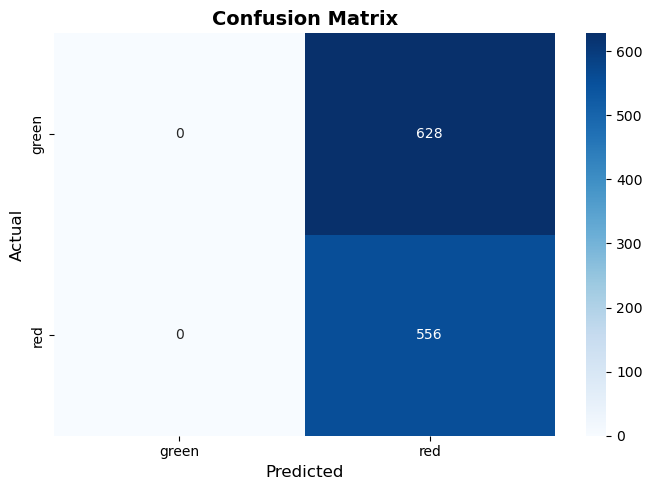


Epoch    26
Train_cost  = 0.6932 | Test_cost  = 0.6943 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 25 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 27 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1004.04it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6943 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

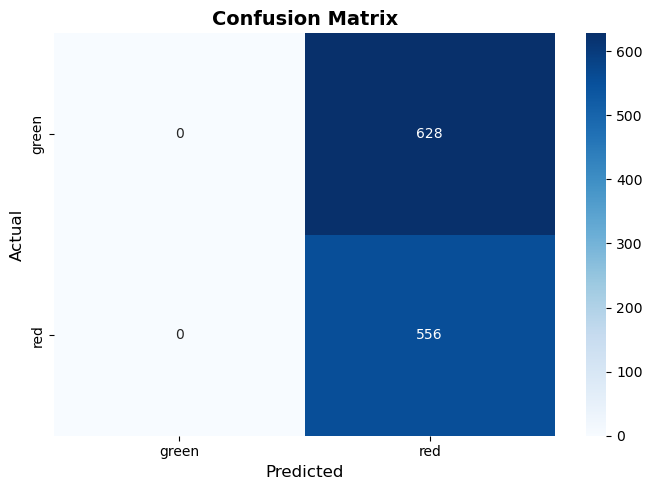


Epoch    27
Train_cost  = 0.6932 | Test_cost  = 0.6943 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 26 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 28 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1124.99it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

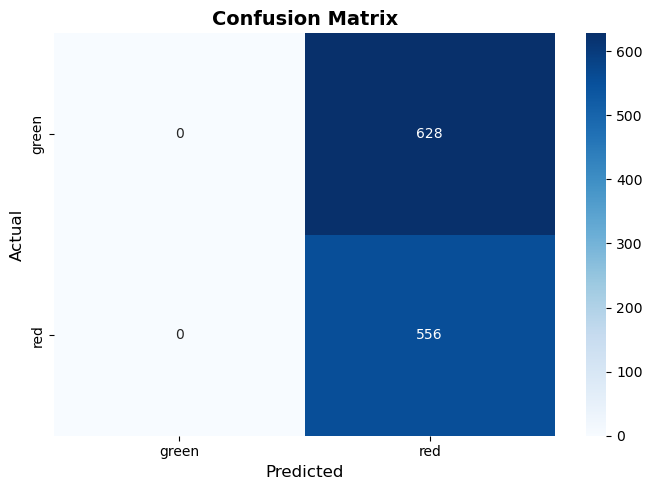


Epoch    28
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 27 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 29 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1103.36it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

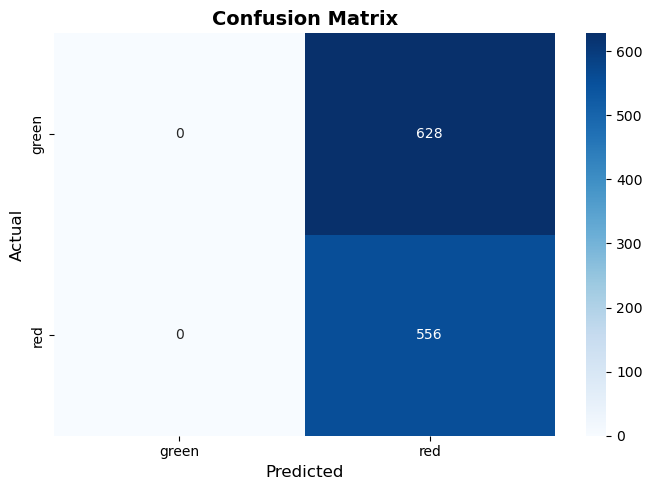


Epoch    29
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 28 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 30 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1116.02it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

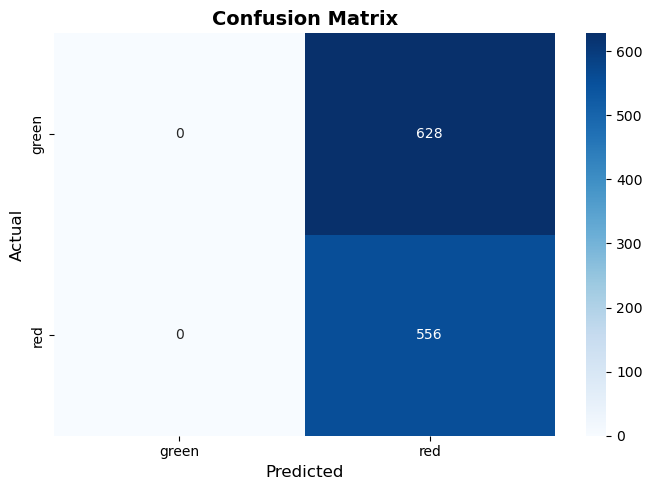


Epoch    30
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 29 | Best test_score: 0.4696


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 37/37 [00:00<00:00, 1114.05it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6944 │ │ green │  0.0000  │
│ Accuracy │ 0.5053 │ 0.4696 │ │  red  │  1.0000  │
│ Macro F1 │ 0.3357 │ 0.3195 │ └───────┴──────────┘
└──────────┴────────┴────────┘

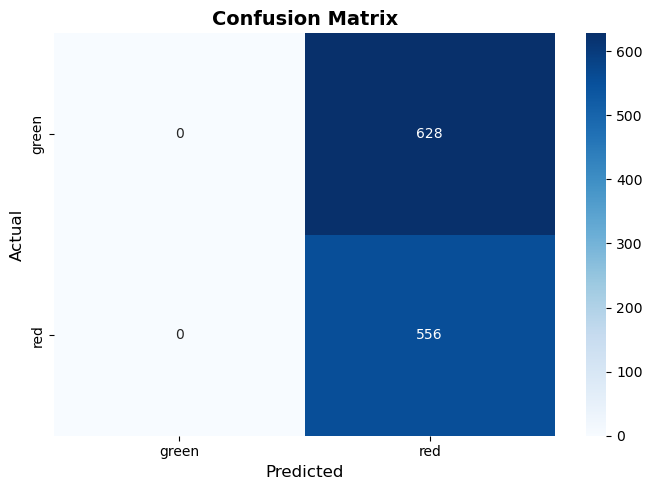


Epoch    31
Train_cost  = 0.6932 | Test_cost  = 0.6944 | Train_score = 0.5053 | Test_score = 0.4696 |
==> EarlyStop patience = 30 | Best test_score: 0.4696
==> Execute Early Stopping at epoch: 31 | Best test_score: 0.4696
==> Best model is saved at timeseris/multi-class-clasification/rnn/microsoft_stock_data/


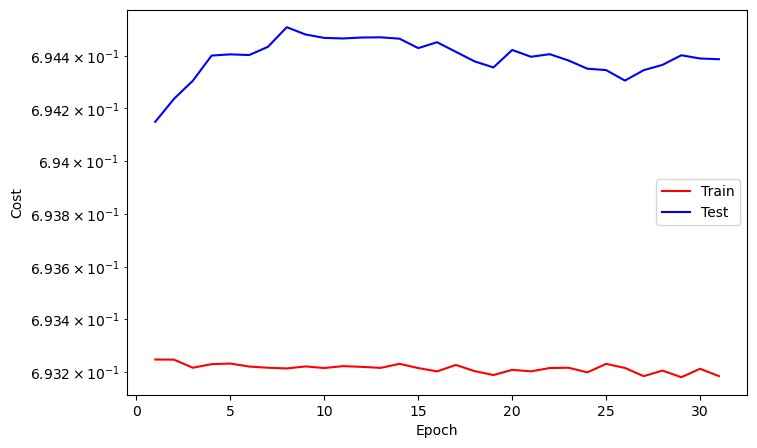

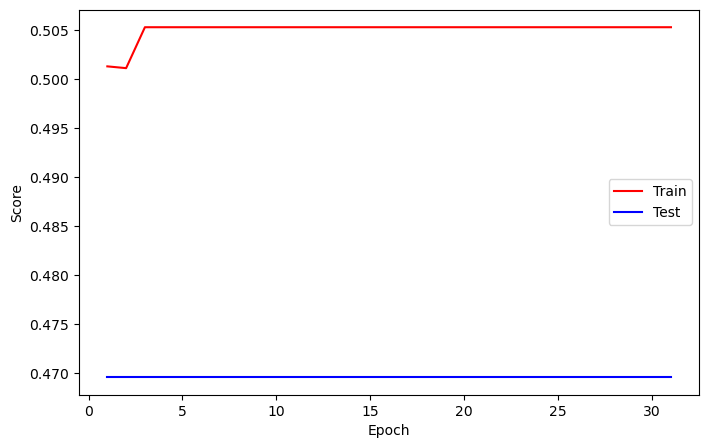

⏹️ Training dihentikan oleh early stopping.

In [75]:
from train_and_evaluate import train_and_evaluate_multi_class

train_and_evaluate_multi_class(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

# Evaluate

      📊 Evaluasi Model            🎯 Per-Class    
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metrik            ┃  Nilai ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┃ Class ┃ Accuracy ┃
│ 💥 Loss (avg)     │ 0.6926 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ 🔹 Accuracy       │ 0.5524 │ │ green │  0.7882  │
│ 📈 Macro F1-score │ 0.5132 │ │  red  │  0.2860  │
└───────────────────┴────────┘ └───────┴──────────┘

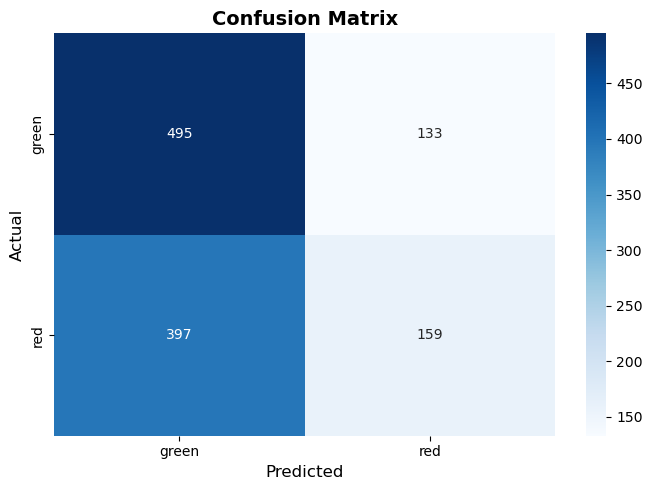

In [69]:
from evaluate import evaluate_multi_class
hsl = evaluate_multi_class(
    model=model,
    dataloader=test_loader,
    labels=labels,
    criterion=criterion,
    device=device,
    dimension='1d'
)

In [70]:
hsl = hsl['df']
b = hsl[hsl['Benar (%)'] == 100]
b.head(300)

,Target,Prediksi,Prob (%),Benar (%),Benar


In [71]:
b.shape

(0, 5)

In [72]:
s = hsl[hsl['Benar (%)'] == 0]
s.head(300)

,Target,Prediksi,Prob (%),Benar (%),Benar


In [73]:
s.shape

(0, 5)